In [31]:
# CELL 17: Define Sequential VAE
class SequentialVAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=8, n_layers=2):
        super().__init__()
        self.latent_dim = latent_dim
        
        # Encoder GRU
        self.encoder_gru = nn.GRU(input_dim, hidden_dim, n_layers, 
                                   batch_first=True, bidirectional=True)
        self.fc_mu = nn.Linear(hidden_dim * 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim * 2, latent_dim)
        
        # Decoder GRU
        self.decoder_fc = nn.Linear(latent_dim, hidden_dim)
        self.decoder_gru = nn.GRU(hidden_dim, hidden_dim, n_layers, batch_first=True)
        self.output_fc = nn.Linear(hidden_dim, input_dim)
        
    def encode(self, x, mask):
        # Pack padded sequence for efficiency
        lengths = mask.sum(dim=1).long().cpu()
        lengths = torch.clamp(lengths, min=1)
        
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, h = self.encoder_gru(packed)
        
        # h shape: (2 * n_layers, batch, hidden_dim)
        # Concatenate last forward and backward hidden states
        h_forward = h[-2, :, :]
        h_backward = h[-1, :, :]
        h_concat = torch.cat([h_forward, h_backward], dim=-1)
        
        mu = self.fc_mu(h_concat)
        logvar = self.fc_logvar(h_concat)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, seq_len):
        batch_size = z.shape[0]
        h = self.decoder_fc(z).unsqueeze(0).repeat(2, 1, 1)
        
        decoder_input = torch.zeros(batch_size, seq_len, h.shape[-1]).to(z.device)
        output, _ = self.decoder_gru(decoder_input, h)
        recon = self.output_fc(output)
        return recon
    
    def forward(self, x, mask):
        mu, logvar = self.encode(x, mask)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z, x.shape[1])
        return recon, mu, logvar

# Initialize model
input_dim = n_features
model = SequentialVAE(input_dim=input_dim, hidden_dim=64, latent_dim=8, n_layers=2).to(device)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

SequentialVAE(
  (encoder_gru): GRU(6, 64, num_layers=2, batch_first=True, bidirectional=True)
  (fc_mu): Linear(in_features=128, out_features=8, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=8, bias=True)
  (decoder_fc): Linear(in_features=8, out_features=64, bias=True)
  (decoder_gru): GRU(64, 64, num_layers=2, batch_first=True)
  (output_fc): Linear(in_features=64, out_features=6, bias=True)
)
Trainable parameters: 155094


In [32]:
# CELL 18: Define weighted loss function
# Weights: recency=10, frequency=5, monetary=2, others=1 (from baseline paper)
# Feature order: recency, frequency, monetary, avg_order_value, quantity, decayed_frequency
feature_weights = torch.FloatTensor([10.0, 5.0, 2.0, 1.0, 1.0, 1.0]).to(device)

def loss_function(recon, x, mask, mu, logvar, beta=1.0):
    """
    Weighted MSE reconstruction loss + KL divergence
    mask: 1 for active months, 0 for padded
    """
    # Weighted MSE
    sq_error = (recon - x) ** 2
    weighted_error = sq_error * feature_weights.unsqueeze(0).unsqueeze(0)
    masked_error = weighted_error * mask.unsqueeze(-1)
    recon_loss = masked_error.sum() / (mask.sum() + 1e-8)
    
    # KL divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

print("Loss function defined.")
print(f"Feature weights: {dict(zip(feature_cols, feature_weights.tolist()))}")

Loss function defined.
Feature weights: {'recency': 10.0, 'frequency': 5.0, 'monetary': 2.0, 'avg_order_value': 1.0, 'quantity': 1.0, 'decayed_frequency': 1.0}


In [33]:
# CELL 19: Train Sequential VAE
def train_vae(model, X, M, epochs=100, batch_size=64, lr=1e-3, beta=0.1):
    dataset = TensorDataset(X, M)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    
    losses = {'total': [], 'recon': [], 'kl': []}
    
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_X, batch_M in loader:
            optimizer.zero_grad()
            recon, mu, logvar = model(batch_X, batch_M)
            loss, recon_l, kl_l = loss_function(recon, batch_X, batch_M, mu, logvar, beta)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(loader)
        losses['total'].append(avg_loss)
        losses['recon'].append(recon_l.item())
        losses['kl'].append(kl_l.item())
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Recon: {recon_l.item():.4f} | KL: {kl_l.item():.4f}")
    
    return losses

print("Starting training...")
losses = train_vae(model, X, M, epochs=100, batch_size=64, lr=1e-3, beta=0.1)

Starting training...
Epoch 20/100 | Loss: 5.1068 | Recon: 6.7279 | KL: 0.9575
Epoch 40/100 | Loss: 4.4607 | Recon: 0.9197 | KL: 0.3911
Epoch 60/100 | Loss: 4.3625 | Recon: 0.7618 | KL: 0.6614
Epoch 80/100 | Loss: 3.9531 | Recon: 2.4326 | KL: 0.6104
Epoch 100/100 | Loss: 3.7733 | Recon: 0.6842 | KL: 0.4431


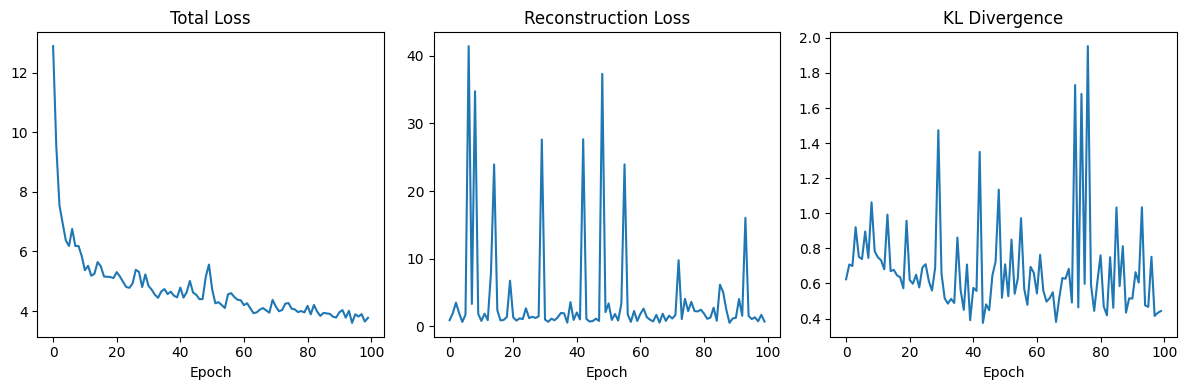

In [34]:
# CELL 20: Plot training loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(losses['total'])
plt.title('Total Loss')
plt.xlabel('Epoch')

plt.subplot(1, 3, 2)
plt.plot(losses['recon'])
plt.title('Reconstruction Loss')
plt.xlabel('Epoch')

plt.subplot(1, 3, 3)
plt.plot(losses['kl'])
plt.title('KL Divergence')
plt.xlabel('Epoch')

plt.tight_layout()
plt.show()

In [35]:
# CELL 21: Extract latent embeddings
model.eval()
with torch.no_grad():
    mu, logvar = model.encode(X, M)
    embeddings = mu.cpu().numpy()

print(f"Latent embedding shape: {embeddings.shape}")
# These are your trajectory-level representations for clustering

Latent embedding shape: (3030, 8)
